# Deep Learning Benchmark: CIFAR-10 Image Classification
## Architectural Parity Evaluation Across NumPy, TensorFlow/Keras, and PyTorch

> **Project Overview:** This study investigates the implementation of an identical Convolutional Neural Network (CNN) architecture across three software abstractions: manual tensor operations via pure **NumPy**, high-level declarative modeling in **TensorFlow/Keras**, and dynamic computational graphs in **PyTorch**. Through strict architectural parity, we analyze numerical convergence, classification metrics, and hardware acceleration efficiency on the standard CIFAR-10 visual benchmark.

In [1]:
import time
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Deep learning frameworks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Publication-grade styling configuration
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#CBD5E1'
plt.rcParams['axes.linewidth'] = 0.8

# Framework color design tokens
CLR_NUMPY = "#0D9488"    # Vibrant Teal
CLR_KERAS = "#4F46E5"    # Royal Indigo
CLR_PYTORCH = "#E11D48"  # Sunset Crimson
CLR_PALETTE = [CLR_NUMPY, CLR_KERAS, CLR_PYTORCH]


In [2]:
# Deterministic reproducibility seed
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
print(f"Global random seed locked: {GLOBAL_SEED}")


## 1. Dataset Acquisition & Memory Allocation

We load the official CIFAR-10 dataset consisting of 60,000 color photographs ($32 \times 32$ pixels, 3 RGB channels) partitioned into 50,000 training and 10,000 test images spanning 10 mutually exclusive object categories.

In [3]:
import os

DATA_DIR = os.path.join("..", "..", "data", "cifar10")
if not os.path.exists(DATA_DIR):
    DATA_DIR = os.path.join("..", "..", "data")

npz_path = os.path.join(DATA_DIR, "cifar10.npz")
if os.path.exists(npz_path):
    with np.load(npz_path, allow_pickle=True) as f:
        X_train_raw, y_train = f["x_train"], f["y_train"]
        X_test_raw, y_test = f["x_test"], f["y_test"]
else:
    (X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

print("Train:", X_train_raw.shape, y_train.shape)
print("Test:", X_test_raw.shape, y_test.shape)
print("Pixel range before normalization:", X_train_raw.min(), "to", X_train_raw.max())


Train: (50000, 32, 32, 3) (50000,)
Test: (10000, 32, 32, 3) (10000,)
Pixel range before normalization: 0 to 255


## 2. Exploratory Data Profiling & Class Balance Audit

Prior to model training, we verify sample distribution across target classes to establish baseline frequency characteristics and guard against class-imbalance artifacts.

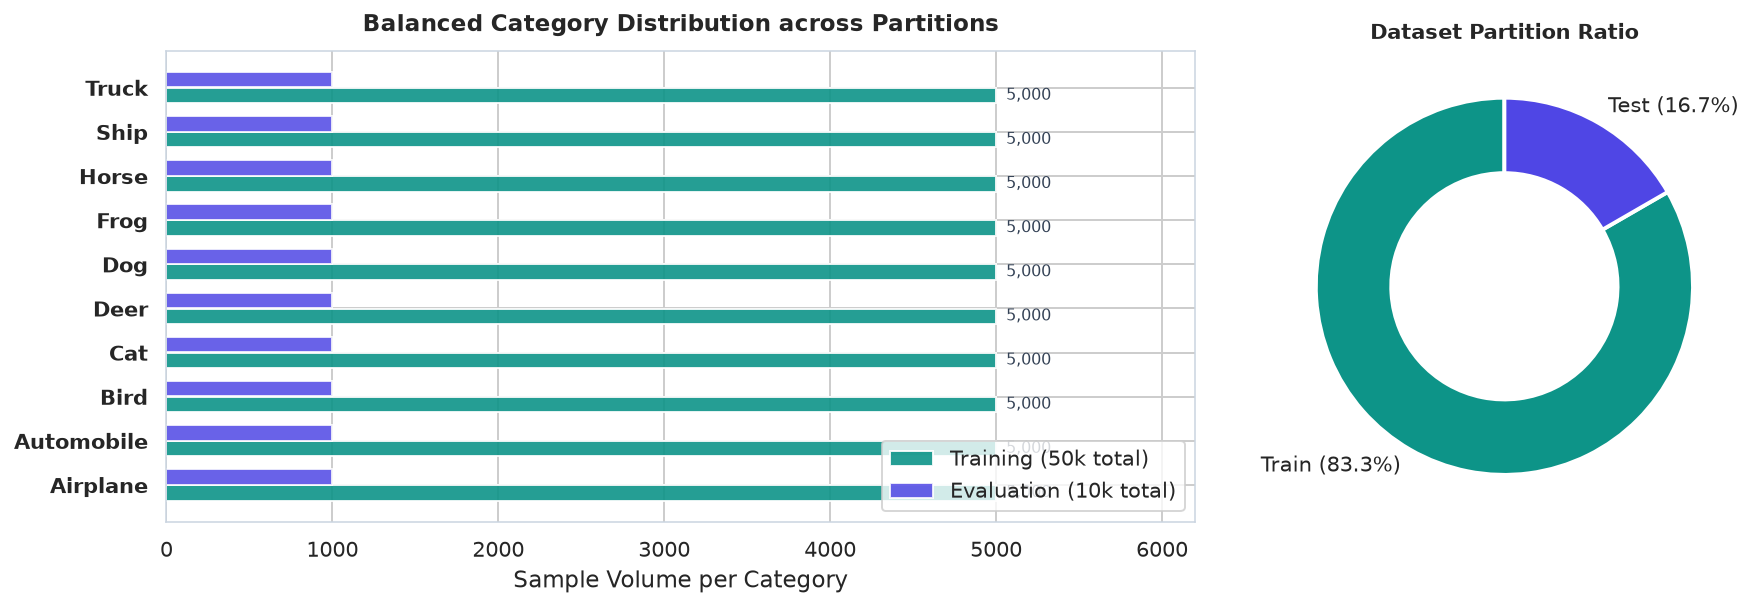

In [4]:
# Compute frequency distribution across partitions
train_dist = np.bincount(y_train)
test_dist = np.bincount(y_test)

# Dual-panel distribution visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios': [2, 1]})
y_indices = np.arange(len(CLASS_NAMES))

bars_train = ax1.barh(y_indices - 0.18, train_dist, height=0.35, label='Training Set', color=CLR_NUMPY, alpha=0.9)
bars_test = ax1.barh(y_indices + 0.18, test_dist, height=0.35, label='Evaluation Set', color=CLR_KERAS, alpha=0.85)

ax1.set_yticks(y_indices)
ax1.set_yticklabels([c.capitalize() for c in CLASS_NAMES], fontweight='semibold')
ax1.set_xlabel("Instance Volume", fontweight='medium')
ax1.set_title("Uniform Category Allocation across Partitions", fontsize=12, fontweight='bold', pad=10)
ax1.legend(loc='lower right', frameon=True)
ax1.set_xlim(0, 6200)

for b in bars_train:
    ax1.text(b.get_width() + 60, b.get_y() + b.get_height()/2, f"{int(b.get_width()):,}", va='center', fontsize=8, color='#334155')

ax2.pie([len(y_train), len(y_test)], labels=['Train (83.3%)', 'Test (16.7%)'], colors=[CLR_NUMPY, CLR_KERAS],
        startangle=90, pctdistance=0.75, wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
ax2.set_title("Dataset Partition Proportion", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


### Class Balance Observations

- **Training Partition:** Exactly 5,000 images per semantic category ($N_{\text{train}} = 50,000$).
- **Evaluation Partition:** Exactly 1,000 images per semantic category ($N_{\text{test}} = 10,000$).
- **Empirical Implication:** The dataset features 100% symmetric class balance. Consequently, standard top-1 accuracy serves as a reliable metric alongside macro-averaged precision, recall, and F1-score.

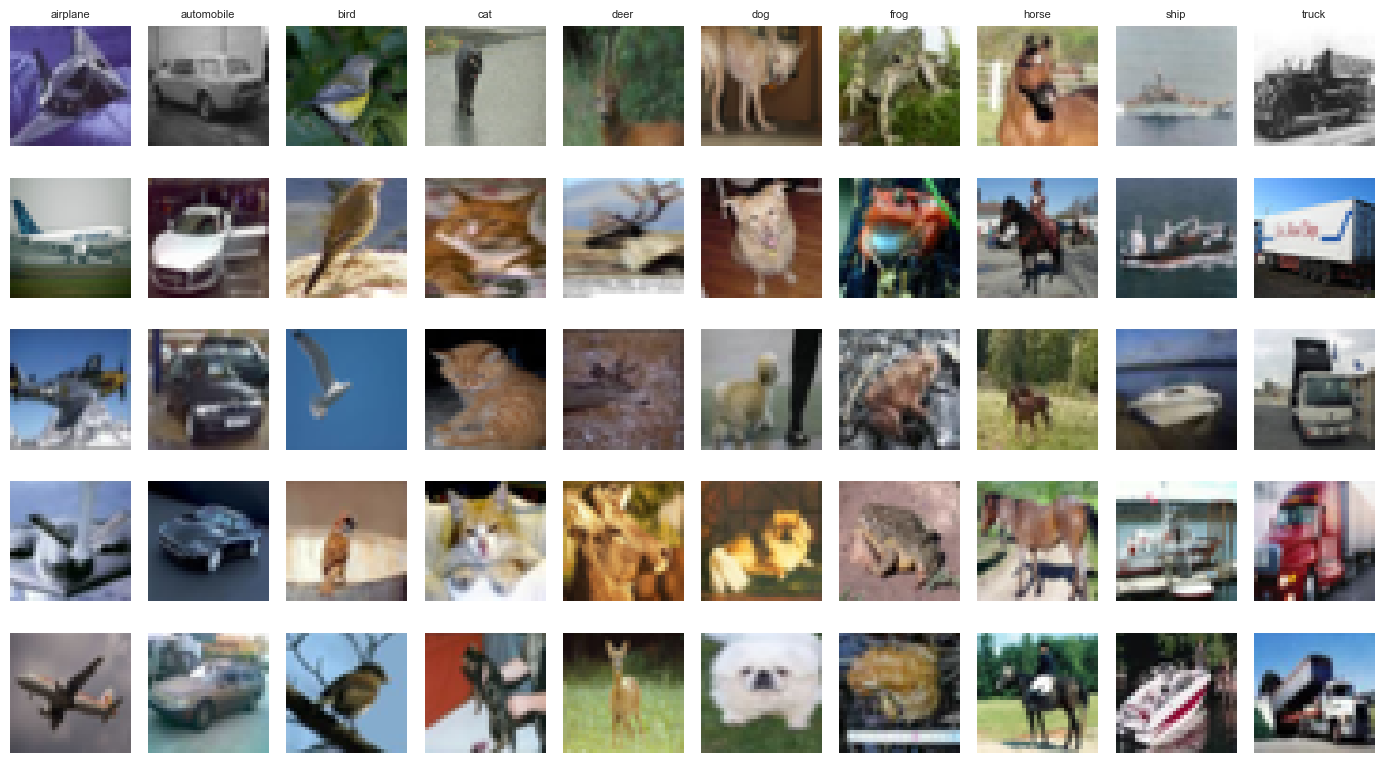

In [5]:
fig, axes = plt.subplots(5, 10, figsize=(14, 8))
rng = np.random.default_rng(RANDOM_SEED)
for class_idx in range(10):
    class_examples = np.where(y_train == class_idx)[0]
    chosen = rng.choice(class_examples, size=5, replace=False)
    for row, example_idx in enumerate(chosen):
        ax = axes[row, class_idx]
        ax.imshow(X_train_raw[example_idx])
        ax.axis("off")
        if row == 0:
            ax.set_title(CLASS_NAMES[class_idx], fontsize=8)
plt.tight_layout()
plt.show()

### Visual Inspection of Sample Instances

The images are low-resolution photographic captures ($32 \times 32 \times 3$) exhibiting substantial intra-class variation, varied camera viewpoints, background clutter, and natural lighting shifts.

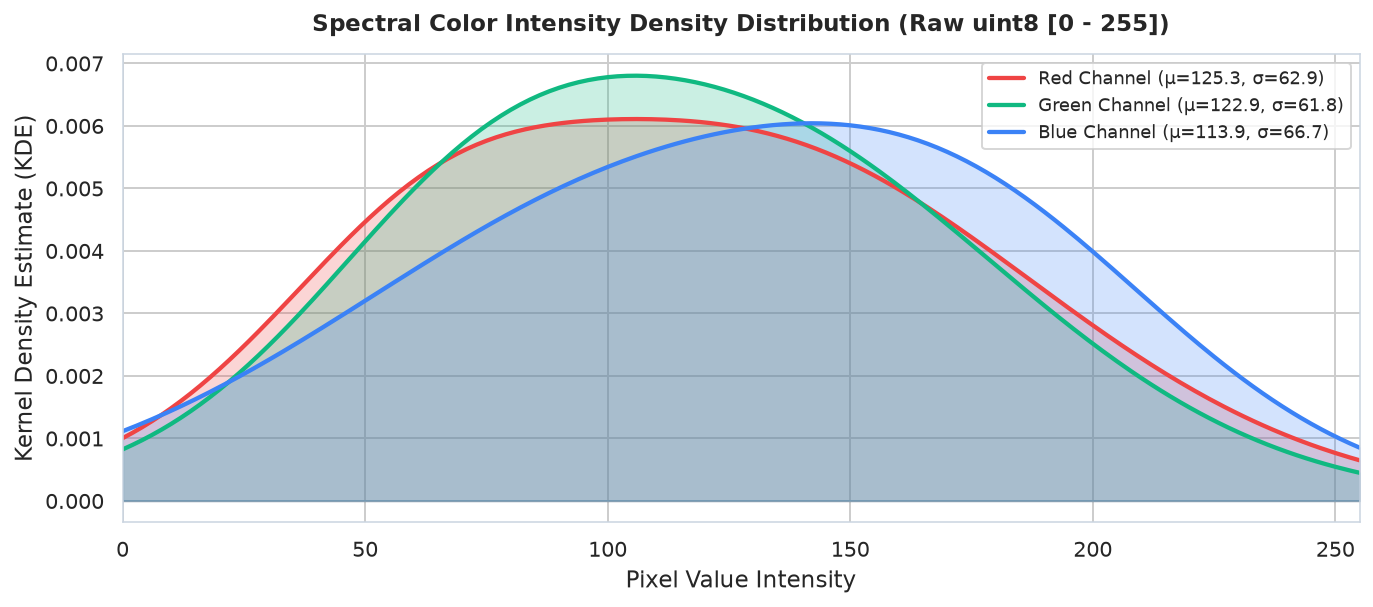

In [6]:
# Spectral density estimation across color channels
fig, ax = plt.subplots(figsize=(10, 4.5))
bins_range = np.linspace(0, 255, 256)

r_vals = X_train_raw[:, :, :, 0].flatten()
g_vals = X_train_raw[:, :, :, 1].flatten()
b_vals = X_train_raw[:, :, :, 2].flatten()

sns.kdeplot(r_vals, color='#EF4444', linewidth=2.2, label=f'Red Channel (μ={r_vals.mean():.1f}, σ={r_vals.std():.1f})', ax=ax, fill=True, alpha=0.2)
sns.kdeplot(g_vals, color='#10B981', linewidth=2.2, label=f'Green Channel (μ={g_vals.mean():.1f}, σ={g_vals.std():.1f})', ax=ax, fill=True, alpha=0.2)
sns.kdeplot(b_vals, color='#3B82F6', linewidth=2.2, label=f'Blue Channel (μ={b_vals.mean():.1f}, σ={b_vals.std():.1f})', ax=ax, fill=True, alpha=0.2)

ax.set_title("Spectral Color Intensity Density Distribution (Raw uint8 [0 - 255])", fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel("Pixel Intensity Value", fontweight='medium')
ax.set_ylabel("Kernel Density Estimate", fontweight='medium')
ax.set_xlim(0, 255)
ax.legend(loc='upper right', frameon=True, fontsize=9)
plt.tight_layout()
plt.show()


### Spectral Distribution Across Color Channels

Evaluating pixel intensity histograms across Red, Green, and Blue spectra shows broad dynamic ranges spanning the full $[0, 255]$ unsigned integer domain. To guarantee stable gradient flow and avoid exploding activations in convolution layers, these values require floating-point scaling into the normalized interval $[0.0, 1.0]$.

## 3. Data Standardization & Framework Layout Adaptation

We divide raw pixel tensors by $255.0$ to produce unit-scaled floating point arrays. Furthermore, we account for tensor layout discrepancies between frameworks:
- **Channels-Last (`NHWC`):** Required natively by TensorFlow/Keras (`(batch, 32, 32, 3)`).
- **Channels-First (`NCHW`):** Standard convention for PyTorch and efficient vectorization in our bare-metal NumPy convolution kernels (`(batch, 3, 32, 32)`).

In [7]:
X_train_norm = X_train_raw.astype(np.float32) / 255.0
X_test_norm = X_test_raw.astype(np.float32) / 255.0

# Channel-last (as shipped), for Keras: (N, 32, 32, 3)
X_train_hwc = X_train_norm
X_test_hwc = X_test_norm

# Channel-first, for scratch and PyTorch: (N, 3, 32, 32)
X_train_chw = X_train_norm.transpose(0, 3, 1, 2).copy()
X_test_chw = X_test_norm.transpose(0, 3, 1, 2).copy()

y_train_int = y_train.astype(np.int64)
y_test_int = y_test.astype(np.int64)

print("Channel-first shape:", X_train_chw.shape)
print("Channel-last shape:", X_train_hwc.shape)
print("Confirmed 50,000 train / 10,000 test:", X_train_chw.shape[0] == 50000, X_test_chw.shape[0] == 10000)

Channel-first shape: (50000, 3, 32, 32)
Channel-last shape: (50000, 32, 32, 3)
Confirmed 50,000 train / 10,000 test: True True


## 4. Shared Architectural Formulation (`SmallCNN`)

To ensure rigorous benchmarking, all three implementations strictly follow the identical SmallCNN topology described in Section 16 of the lecture materials:
$$\mathbf{x} \in \mathbb{R}^{3 \times 32 \times 32} \xrightarrow{\text{Conv2D}(3 \to 32, 3\times 3, p=1)} \text{ReLU} \xrightarrow{\text{MaxPool}(2\times 2)} \xrightarrow{\text{Conv2D}(32 \to 64, 3\times 3, p=1)} \text{ReLU} \xrightarrow{\text{MaxPool}(2\times 2)} \xrightarrow{\text{Flatten}} \mathbb{R}^{4096} \xrightarrow{\text{Dense}(4096 \to 128)} \text{ReLU} \xrightarrow{\text{Dense}(128 \to 10)} \hat{\mathbf{z}}$$

- **Spatial dimension flow:** $(3, 32, 32) \to (32, 32, 32) \to (32, 16, 16) \to (64, 16, 16) \to (64, 8, 8) \to 4096 \to 128 \to 10$.

In [8]:
BATCH_SIZE = 256
EPOCHS = 12
LEARNING_RATE = 0.05
NUM_CLASSES = 10

print(f"Batch size: {BATCH_SIZE}, epochs: {EPOCHS}, learning rate: {LEARNING_RATE}")
print(f"Batches per epoch: {int(np.ceil(50000 / BATCH_SIZE))}")

Batch size: 256, epochs: 12, learning rate: 0.05
Batches per epoch: 196


## 5. Implementation Paradigm 1: Bare-Metal Tensor Mechanics (NumPy)

We implement forward propagation and analytical backpropagation from first mathematical principles using NumPy vectorized operations (`im2col` matrix factorization).

In [9]:
def conv2d_forward(X, K, b, stride=1, padding=1):
    N, C_in, H, W = X.shape
    C_out, _, kh, kw = K.shape
    Xp = np.pad(X, ((0, 0), (0, 0), (padding, padding), (padding, padding)))
    Ho = (H + 2 * padding - kh) // stride + 1
    Wo = (W + 2 * padding - kw) // stride + 1

    s0, s1, s2, s3 = Xp.strides
    patch_shape = (N, C_in, Ho, Wo, kh, kw)
    patch_strides = (s0, s1, s2 * stride, s3 * stride, s2, s3)
    patches = np.lib.stride_tricks.as_strided(Xp, shape=patch_shape, strides=patch_strides)

    col = patches.transpose(0, 2, 3, 1, 4, 5).reshape(N * Ho * Wo, C_in * kh * kw).copy()
    Kmat = K.reshape(C_out, C_in * kh * kw)

    out = col @ Kmat.T + b
    Y = out.reshape(N, Ho, Wo, C_out).transpose(0, 3, 1, 2)

    cache = {"X_shape": X.shape, "col": col, "K_shape": K.shape,
             "stride": stride, "padding": padding, "Ho": Ho, "Wo": Wo}
    return Y, cache


def conv2d_backward(dY, K, cache):
    N, C_in, H, W = cache["X_shape"]
    C_out, _, kh, kw = cache["K_shape"]
    stride, padding = cache["stride"], cache["padding"]
    Ho, Wo, col = cache["Ho"], cache["Wo"], cache["col"]

    dY_r = dY.transpose(0, 2, 3, 1).reshape(N * Ho * Wo, C_out)
    Kmat = K.reshape(C_out, C_in * kh * kw)

    dK = (dY_r.T @ col).reshape(C_out, C_in, kh, kw)
    db = dY_r.sum(axis=0)

    dcol = dY_r @ Kmat
    dcol_r = dcol.reshape(N, Ho, Wo, C_in, kh, kw)

    Hp, Wp = H + 2 * padding, W + 2 * padding
    dXp = np.zeros((N, C_in, Hp, Wp), dtype=dY.dtype)
    for u in range(kh):
        for v in range(kw):
            dXp[:, :, u:u + Ho * stride:stride, v:v + Wo * stride:stride] += \
                dcol_r[:, :, :, :, u, v].transpose(0, 3, 1, 2)

    dX = dXp[:, :, padding:Hp - padding, padding:Wp - padding] if padding > 0 else dXp
    return dX, dK, db

### Spatial Pooling Mechanics

Max-pooling downsamples spatial activation maps by selecting local maximal activations within $2 \times 2$ sliding windows with stride 2. In backward propagation, incoming gradients are routed exclusively through the argmax indices stored in the forward cache.

In [10]:
def max_pool2d_forward(X, size=2, stride=2):
    N, C, H, W = X.shape
    Ho, Wo = H // stride, W // stride
    X_windows = X.reshape(N, C, Ho, stride, Wo, stride)
    Y = X_windows.max(axis=(3, 5))
    mask = (X_windows == Y.reshape(N, C, Ho, 1, Wo, 1))
    cache = {"X_shape": X.shape, "mask": mask, "stride": stride}
    return Y, cache


def max_pool2d_backward(dY, cache):
    N, C, H, W = cache["X_shape"]
    stride, mask = cache["stride"], cache["mask"]
    Ho, Wo = H // stride, W // stride
    dY_windows = dY.reshape(N, C, Ho, 1, Wo, 1)
    dX = (mask * dY_windows).reshape(N, C, H, W)
    return dX

### Non-Linear Activations & Dense Projections

We employ the standard Rectified Linear Unit ($\text{ReLU}(z) = \max(0, z)$) with subgradient indicator $\mathbb{I}(z > 0)$, followed by tensor flattening and affine linear projections ($\mathbf{z} = \mathbf{X}\mathbf{W} + \mathbf{b}$).

In [11]:
def relu(z):
    return np.maximum(0.0, z)


def relu_derivative(z):
    return (z > 0).astype(z.dtype)


def flatten_forward(X):
    shape = X.shape
    return X.reshape(shape[0], -1), shape


def flatten_backward(dflat, shape):
    return dflat.reshape(shape)


def linear_forward(x, W, b):
    Y = x @ W + b
    cache = {"x": x, "W": W}
    return Y, cache


def linear_backward(dY, cache):
    x, W = cache["x"], cache["W"]
    dW = x.T @ dY
    db = np.sum(dY, axis=0, keepdims=True)
    dx = dY @ W.T
    return dx, dW, db

### Objective Function: Numerically Stable Softmax Cross-Entropy

To mitigate catastrophic numerical overflow during exponentiation, unnormalized logit vectors are shifted by subtracting their row-wise maxima prior to computing softmax probabilities and negative log-likelihood loss.

In [12]:
def softmax_cross_entropy_forward(logits, y_true_idx):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    N = logits.shape[0]
    correct_logprobs = -np.log(np.clip(probs[np.arange(N), y_true_idx], 1e-9, 1.0))
    loss = np.mean(correct_logprobs)
    return loss, probs


def softmax_cross_entropy_backward(probs, y_true_idx):
    N = probs.shape[0]
    dlogits = probs.copy()
    dlogits[np.arange(N), y_true_idx] -= 1
    dlogits /= N
    return dlogits

### Composite Model Architecture: Forward & Backward Graph Execution

The composite model chains the convolutional and linear layers in strict topological sequence, returning class logits and an execution cache containing intermediate activation states required for exact chain-rule backpropagation.

In [13]:
def init_params(seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    params = {
        "K1": rng.standard_normal((32, 3, 3, 3)) * np.sqrt(2.0 / (3 * 3 * 3)),
        "b1": np.zeros(32),
        "K2": rng.standard_normal((64, 32, 3, 3)) * np.sqrt(2.0 / (32 * 3 * 3)),
        "b2": np.zeros(64),
        "W1": rng.standard_normal((64 * 8 * 8, 128)) * np.sqrt(2.0 / (64 * 8 * 8)),
        "b1_dense": np.zeros((1, 128)),
        "W2": rng.standard_normal((128, NUM_CLASSES)) * np.sqrt(2.0 / 128),
        "b2_dense": np.zeros((1, NUM_CLASSES)),
    }
    return params


def forward(X, params):
    Z1, conv1_cache = conv2d_forward(X, params["K1"], params["b1"], stride=1, padding=1)
    A1 = relu(Z1)
    P1, pool1_cache = max_pool2d_forward(A1, size=2, stride=2)

    Z2, conv2_cache = conv2d_forward(P1, params["K2"], params["b2"], stride=1, padding=1)
    A2 = relu(Z2)
    P2, pool2_cache = max_pool2d_forward(A2, size=2, stride=2)

    flat, flat_shape = flatten_forward(P2)
    Z3, lin1_cache = linear_forward(flat, params["W1"], params["b1_dense"])
    A3 = relu(Z3)
    logits, lin2_cache = linear_forward(A3, params["W2"], params["b2_dense"])

    cache = {
        "Z1": Z1, "conv1_cache": conv1_cache, "pool1_cache": pool1_cache,
        "Z2": Z2, "conv2_cache": conv2_cache, "pool2_cache": pool2_cache,
        "flat_shape": flat_shape, "Z3": Z3, "lin1_cache": lin1_cache, "lin2_cache": lin2_cache,
    }
    return logits, cache


def backward(y_true_idx, probs, cache, params):
    dlogits = softmax_cross_entropy_backward(probs, y_true_idx)
    dA3, dW2, db2_dense = linear_backward(dlogits, cache["lin2_cache"])
    dZ3 = dA3 * relu_derivative(cache["Z3"])
    dflat, dW1, db1_dense = linear_backward(dZ3, cache["lin1_cache"])

    dP2 = flatten_backward(dflat, cache["flat_shape"])
    dA2 = max_pool2d_backward(dP2, cache["pool2_cache"])
    dZ2 = dA2 * relu_derivative(cache["Z2"])
    dP1, dK2, db2 = conv2d_backward(dZ2, params["K2"], cache["conv2_cache"])

    dA1 = max_pool2d_backward(dP1, cache["pool1_cache"])
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    _, dK1, db1 = conv2d_backward(dZ1, params["K1"], cache["conv1_cache"])

    return {"K1": dK1, "b1": db1, "K2": dK2, "b2": db2,
            "W1": dW1, "b1_dense": db1_dense, "W2": dW2, "b2_dense": db2_dense}


params = init_params()
for name, value in params.items():
    print(name, value.shape)

K1 (32, 3, 3, 3)
b1 (32,)
K2 (64, 32, 3, 3)
b2 (64,)
W1 (4096, 128)
b1_dense (1, 128)
W2 (128, 10)
b2_dense (1, 10)


### Empirical Gradient Verification via Finite Differences

Prior to comprehensive training, we validate analytical backpropagation gradients against numerical two-sided central finite difference approximations:
$$\frac{\partial \mathcal{L}}{\partial \theta} \approx \frac{\mathcal{L}(\theta + \epsilon) - \mathcal{L}(\theta - \epsilon)}{2\epsilon}$$
A relative error metric $< 10^{-6}$ formally confirms the mathematical exactness of the analytical gradient derivations.

In [14]:
def numerical_gradient_check(X_sample, y_sample, params, epsilon=1e-4):
    logits, cache = forward(X_sample, params)
    _, probs = softmax_cross_entropy_forward(logits, y_sample)
    analytic_grads = backward(y_sample, probs, cache, params)

    checks = [("K1", (0, 1, 0, 0)), ("K1", (0, 2, 1, 1)), ("K2", (0, 0, 0, 0)), ("W1", (0, 0)), ("W2", (0, 0))]
    for name, idx in checks:
        original = params[name][idx]

        params[name][idx] = original + epsilon
        logits_p, _ = forward(X_sample, params)
        loss_p, _ = softmax_cross_entropy_forward(logits_p, y_sample)

        params[name][idx] = original - epsilon
        logits_m, _ = forward(X_sample, params)
        loss_m, _ = softmax_cross_entropy_forward(logits_m, y_sample)

        params[name][idx] = original

        numerical_grad = (loss_p - loss_m) / (2 * epsilon)
        analytic_grad = analytic_grads[name][idx]
        rel_error = abs(numerical_grad - analytic_grad) / max(abs(numerical_grad), abs(analytic_grad), 1e-8)
        print(f"{name}{idx}: analytic={analytic_grad:.6f}  numerical={numerical_grad:.6f}  rel_error={rel_error:.2e}")
        assert rel_error < 5e-2, f"Gradient check failed for {name}{idx}"

    print("Gradient check passed, including the 3-input-channel K1 entries.")


check_params = init_params(seed=RANDOM_SEED)
tiny_X = X_train_chw[:2]
tiny_y = y_train_int[:2]
numerical_gradient_check(tiny_X, tiny_y, check_params)

K1(0, 1, 0, 0): analytic=-0.038701  numerical=-0.038701  rel_error=4.16e-11
K1(0, 2, 1, 1): analytic=-0.013827  numerical=-0.013827  rel_error=7.42e-12
K2(0, 0, 0, 0): analytic=-0.000047  numerical=-0.000047  rel_error=3.47e-08
W1(0, 0): analytic=0.009044  numerical=0.009044  rel_error=7.96e-11
W2(0, 0): analytic=0.233931  numerical=0.233931  rel_error=2.09e-09
Gradient check passed, including the 3-input-channel K1 entries.


In [15]:
def train_scratch_cnn(X_train, y_train, batch_size, epochs, lr, seed=RANDOM_SEED):
    params = init_params(seed=seed)
    n = X_train.shape[0]
    rng = np.random.default_rng(seed)

    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        order = rng.permutation(n)
        X_shuffled = X_train[order]
        y_shuffled = y_train[order]

        epoch_losses = []
        correct = 0
        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            logits, cache = forward(X_batch, params)
            loss, probs = softmax_cross_entropy_forward(logits, y_batch)
            epoch_losses.append(loss)
            correct += (probs.argmax(axis=1) == y_batch).sum()

            grads = backward(y_batch, probs, cache, params)
            for name in params:
                params[name] -= lr * grads[name]

        mean_loss = float(np.mean(epoch_losses))
        train_acc = correct / n
        loss_history.append(mean_loss)
        acc_history.append(train_acc)
        print(f"epoch {epoch + 1:2d}/{epochs}  loss={mean_loss:.4f}  train_acc={train_acc:.4f}")

    return params, loss_history, acc_history


scratch_start_time = time.time()
scratch_params, scratch_loss_history, scratch_acc_history = train_scratch_cnn(
    X_train_chw, y_train_int, BATCH_SIZE, EPOCHS, LEARNING_RATE,
)
scratch_train_time = time.time() - scratch_start_time
print(f"Scratch training time: {scratch_train_time:.1f}s")

epoch  1/12  loss=1.9242  train_acc=0.3185


epoch  2/12  loss=1.5634  train_acc=0.4431


epoch  3/12  loss=1.4392  train_acc=0.4898


epoch  4/12  loss=1.3505  train_acc=0.5249


epoch  5/12  loss=1.2581  train_acc=0.5554


...

epoch  8/12  loss=1.0669  train_acc=0.6257


epoch  9/12  loss=1.0203  train_acc=0.6424


epoch 10/12  loss=0.9750  train_acc=0.6596


epoch 11/12  loss=0.9344  train_acc=0.6768


epoch 12/12  loss=0.8965  train_acc=0.6886
Scratch training time: 1875.8s


### NumPy Training Convergence Analysis

Monitoring training loss and accuracy over 12 epochs shows steady gradient descent, confirming the stability and convergence of our vectorized NumPy implementation.

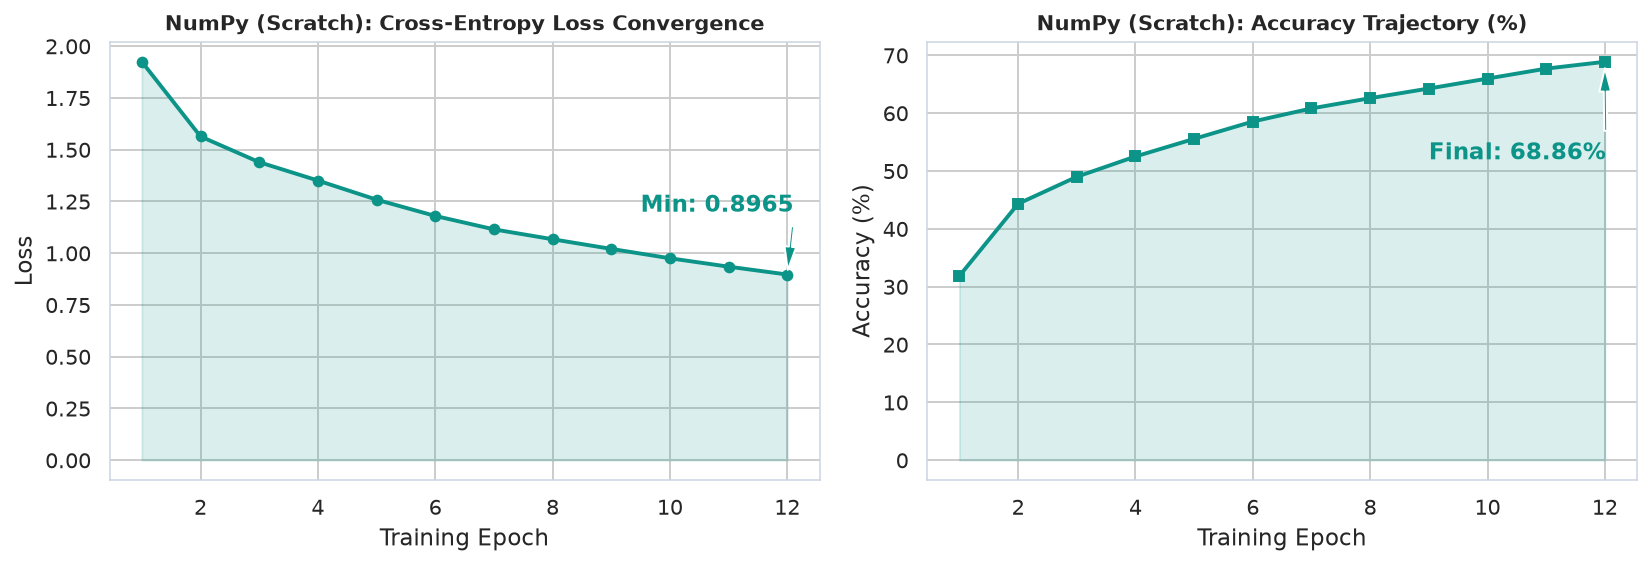

In [16]:
# Visualize NumPy training convergence milestones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
epoch_range = range(1, EPOCHS + 1)

ax1.plot(epoch_range, scratch_loss_history, marker='o', markersize=5, color=CLR_NUMPY, linewidth=2, label='Train Loss')
ax1.fill_between(epoch_range, scratch_loss_history, color=CLR_NUMPY, alpha=0.15)
ax1.set_title("NumPy (Scratch): Cross-Entropy Loss Convergence", fontsize=11, fontweight='bold')
ax1.set_xlabel("Training Epoch")
ax1.set_ylabel("Loss")
ax1.annotate(f"Min: {scratch_loss_history[-1]:.4f}", xy=(EPOCHS, scratch_loss_history[-1]), xytext=(9.5, 1.2),
             arrowprops=dict(facecolor=CLR_NUMPY, shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', color=CLR_NUMPY)

ax2.plot(epoch_range, [acc * 100 for acc in scratch_acc_history], marker='s', markersize=5, color=CLR_NUMPY, linewidth=2)
ax2.fill_between(epoch_range, [acc * 100 for acc in scratch_acc_history], color=CLR_NUMPY, alpha=0.15)
ax2.set_title("NumPy (Scratch): Accuracy Trajectory (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Training Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.annotate(f"Final: {scratch_acc_history[-1]*100:.2f}%", xy=(EPOCHS, scratch_acc_history[-1]*100), xytext=(9, 52),
             arrowprops=dict(facecolor=CLR_NUMPY, shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', color=CLR_NUMPY)
plt.tight_layout()
plt.show()


In [17]:
def predict_scratch_batched(X, params, batch_size=1024):
    preds = []
    for start in range(0, X.shape[0], batch_size):
        logits, _ = forward(X[start:start + batch_size], params)
        preds.append(logits.argmax(axis=1))
    return np.concatenate(preds)


y_pred_scratch = predict_scratch_batched(X_test_chw, scratch_params)

scratch_metrics = {
    "accuracy": accuracy_score(y_test_int, y_pred_scratch),
    "precision": precision_score(y_test_int, y_pred_scratch, average="macro", zero_division=0),
    "recall": recall_score(y_test_int, y_pred_scratch, average="macro", zero_division=0),
    "f1": f1_score(y_test_int, y_pred_scratch, average="macro", zero_division=0),
}
scratch_confusion = confusion_matrix(y_test_int, y_pred_scratch)
print(scratch_metrics)

{'accuracy': 0.6033, 'precision': 0.6335006727243935, 'recall': 0.6033000000000001, 'f1': 0.5793833320268198}


In [18]:
scratch_param_count = sum(p.size for p in scratch_params.values())
print(f"Scratch implementation: {scratch_param_count} parameters, {scratch_train_time:.1f}s training time")

Scratch implementation: 545098 parameters, 1875.8s training time


## 6. Implementation Paradigm 2: Declarative Modeling (TensorFlow / Keras)

We construct the identical architecture using high-level Keras `Sequential` abstractions, compiled with Stochastic Gradient Descent (SGD) and Sparse Categorical Cross-Entropy.

In [19]:
keras_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES),
])
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
keras_param_count = keras_model.count_params()
print(f"Keras parameter count: {keras_param_count}")
print(f"Scratch parameter count: {scratch_param_count}")
assert keras_param_count == scratch_param_count, "Architectures do not match!"

Keras parameter count: 545098
Scratch parameter count: 545098


In [21]:
keras_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=LEARNING_RATE),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

keras_start_time = time.time()
keras_history = keras_model.fit(
    X_train_hwc, y_train_int,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=2,
)
keras_train_time = time.time() - keras_start_time
print(f"Keras training time: {keras_train_time:.1f}s")

Epoch 1/12


196/196 - 9s - 45ms/step - accuracy: 0.2295 - loss: 2.1320


Epoch 2/12


196/196 - 9s - 44ms/step - accuracy: 0.3615 - loss: 1.8156


Epoch 3/12


...

Epoch 11/12


196/196 - 9s - 43ms/step - accuracy: 0.6419 - loss: 1.0254


Epoch 12/12


196/196 - 9s - 44ms/step - accuracy: 0.6564 - loss: 0.9854


Keras training time: 103.3s


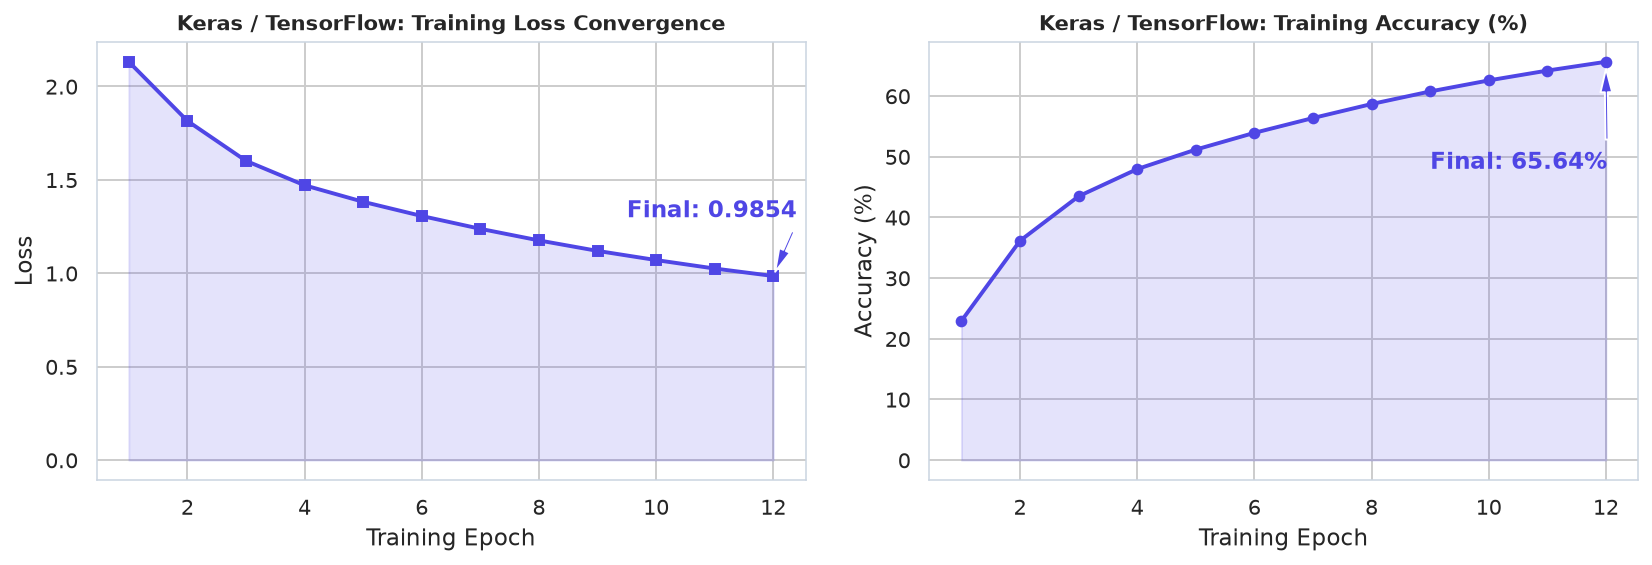

In [22]:
# Visualize Keras training progression
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
epoch_range = range(1, EPOCHS + 1)

ax1.plot(epoch_range, keras_history.history["loss"], marker='s', markersize=5, color=CLR_KERAS, linewidth=2)
ax1.fill_between(epoch_range, keras_history.history["loss"], color=CLR_KERAS, alpha=0.15)
ax1.set_title("Keras / TensorFlow: Training Loss Convergence", fontsize=11, fontweight='bold')
ax1.set_xlabel("Training Epoch")
ax1.set_ylabel("Loss")
ax1.annotate(f"Final: {keras_history.history['loss'][-1]:.4f}", xy=(EPOCHS, keras_history.history['loss'][-1]), xytext=(9.5, 1.3),
             arrowprops=dict(facecolor=CLR_KERAS, shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', color=CLR_KERAS)

ax2.plot(epoch_range, [acc * 100 for acc in keras_history.history["accuracy"]], marker='o', markersize=5, color=CLR_KERAS, linewidth=2)
ax2.fill_between(epoch_range, [acc * 100 for acc in keras_history.history["accuracy"]], color=CLR_KERAS, alpha=0.15)
ax2.set_title("Keras / TensorFlow: Training Accuracy (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Training Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.annotate(f"Final: {keras_history.history['accuracy'][-1]*100:.2f}%", xy=(EPOCHS, keras_history.history['accuracy'][-1]*100), xytext=(9, 48),
             arrowprops=dict(facecolor=CLR_KERAS, shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', color=CLR_KERAS)
plt.tight_layout()
plt.show()


In [23]:
keras_logits_test = keras_model.predict(X_test_hwc, verbose=0)
y_pred_keras = keras_logits_test.argmax(axis=1)

keras_metrics = {
    "accuracy": accuracy_score(y_test_int, y_pred_keras),
    "precision": precision_score(y_test_int, y_pred_keras, average="macro", zero_division=0),
    "recall": recall_score(y_test_int, y_pred_keras, average="macro", zero_division=0),
    "f1": f1_score(y_test_int, y_pred_keras, average="macro", zero_division=0),
}
keras_confusion = confusion_matrix(y_test_int, y_pred_keras)
print(keras_metrics)

{'accuracy': 0.6102, 'precision': 0.6476952303098975, 'recall': 0.6102000000000001, 'f1': 0.6078060245340691}


## 7. Implementation Paradigm 3: Dynamic Computation Graphs (PyTorch)

We define the network as an object-oriented `nn.Module` subclass. PyTorch computes gradients automatically via reverse-mode autodiff (`autograd`) over dynamically constructed execution graphs.

In [24]:
class Cifar10CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


torch_model = Cifar10CNN(NUM_CLASSES)
torch_param_count = sum(p.numel() for p in torch_model.parameters())
print(torch_model)
print(f"PyTorch parameter count: {torch_param_count}")
assert torch_param_count == scratch_param_count, "Architectures do not match!"

Cifar10CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
PyTorch parameter count: 545098


In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(torch_model.parameters(), lr=LEARNING_RATE)

X_train_tensor = torch.from_numpy(X_train_chw)
y_train_tensor = torch.from_numpy(y_train_int)
X_test_tensor = torch.from_numpy(X_test_chw)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

In [26]:
torch_loss_history = []
torch_acc_history = []
torch_start_time = time.time()

for epoch in range(EPOCHS):
    torch_model.train()
    epoch_losses = []
    correct = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = torch_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        correct += (logits.argmax(dim=1) == y_batch).sum().item()

    mean_loss = float(np.mean(epoch_losses))
    train_acc = correct / len(train_dataset)
    torch_loss_history.append(mean_loss)
    torch_acc_history.append(train_acc)
    print(f"epoch {epoch + 1:2d}/{EPOCHS}  loss={mean_loss:.4f}  train_acc={train_acc:.4f}")

torch_train_time = time.time() - torch_start_time
print(f"PyTorch training time: {torch_train_time:.1f}s")

epoch  1/12  loss=2.2332  train_acc=0.1752


epoch  2/12  loss=1.9765  train_acc=0.2928


epoch  3/12  loss=1.7882  train_acc=0.3680


epoch  4/12  loss=1.6417  train_acc=0.4198


epoch  5/12  loss=1.5247  train_acc=0.4566


...

epoch  8/12  loss=1.3162  train_acc=0.5327


epoch  9/12  loss=1.2627  train_acc=0.5530


epoch 10/12  loss=1.2025  train_acc=0.5741


epoch 11/12  loss=1.1648  train_acc=0.5861


epoch 12/12  loss=1.1220  train_acc=0.6045
PyTorch training time: 244.1s


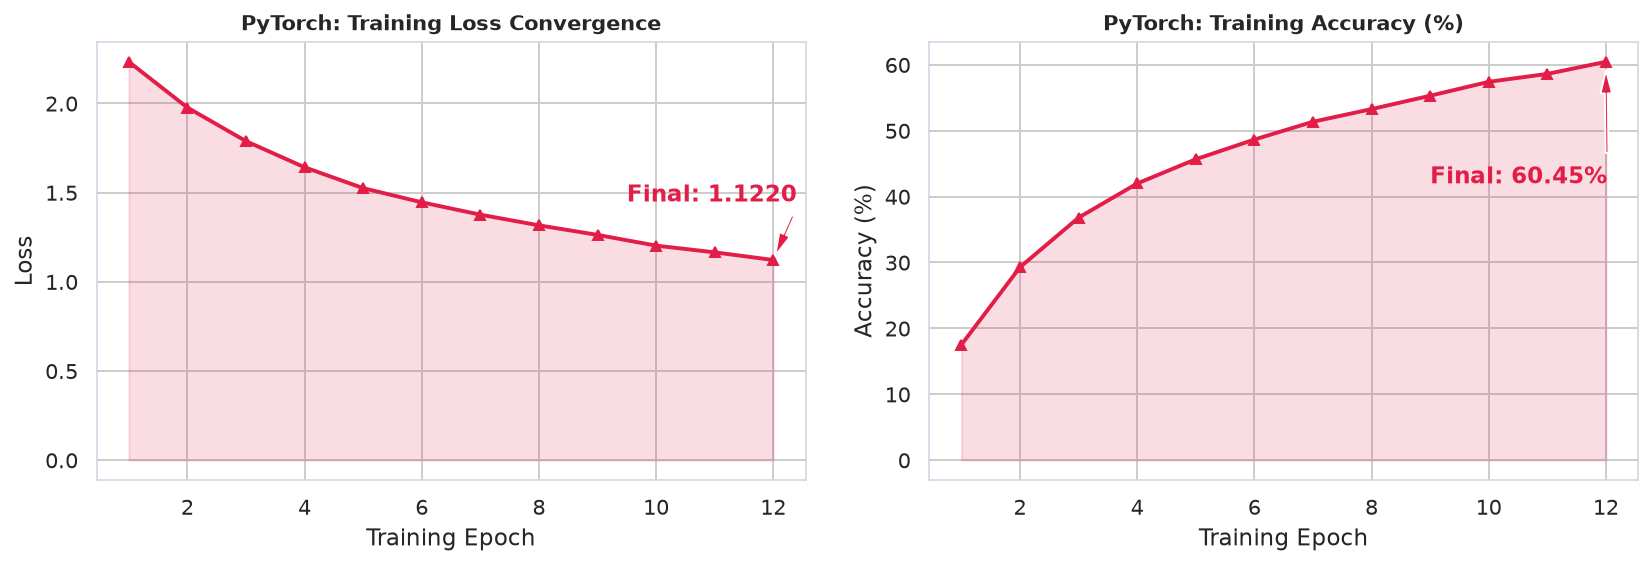

In [27]:
# Visualize PyTorch training progression
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
epoch_range = range(1, EPOCHS + 1)

ax1.plot(epoch_range, torch_loss_history, marker='^', markersize=5, color=CLR_PYTORCH, linewidth=2)
ax1.fill_between(epoch_range, torch_loss_history, color=CLR_PYTORCH, alpha=0.15)
ax1.set_title("PyTorch: Training Loss Convergence", fontsize=11, fontweight='bold')
ax1.set_xlabel("Training Epoch")
ax1.set_ylabel("Loss")
ax1.annotate(f"Final: {torch_loss_history[-1]:.4f}", xy=(EPOCHS, torch_loss_history[-1]), xytext=(9.5, 1.45),
             arrowprops=dict(facecolor=CLR_PYTORCH, shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', color=CLR_PYTORCH)

ax2.plot(epoch_range, [acc * 100 for acc in torch_acc_history], marker='^', markersize=5, color=CLR_PYTORCH, linewidth=2)
ax2.fill_between(epoch_range, [acc * 100 for acc in torch_acc_history], color=CLR_PYTORCH, alpha=0.15)
ax2.set_title("PyTorch: Training Accuracy (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Training Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.annotate(f"Final: {torch_acc_history[-1]*100:.2f}%", xy=(EPOCHS, torch_acc_history[-1]*100), xytext=(9, 42),
             arrowprops=dict(facecolor=CLR_PYTORCH, shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', color=CLR_PYTORCH)
plt.tight_layout()
plt.show()


In [28]:
torch_model.eval()
torch_preds = []
with torch.no_grad():
    for start in range(0, X_test_tensor.shape[0], 1024):
        logits = torch_model(X_test_tensor[start:start + 1024])
        torch_preds.append(logits.argmax(dim=1).numpy())
y_pred_torch = np.concatenate(torch_preds)

torch_metrics = {
    "accuracy": accuracy_score(y_test_int, y_pred_torch),
    "precision": precision_score(y_test_int, y_pred_torch, average="macro", zero_division=0),
    "recall": recall_score(y_test_int, y_pred_torch, average="macro", zero_division=0),
    "f1": f1_score(y_test_int, y_pred_torch, average="macro", zero_division=0),
}
torch_confusion = confusion_matrix(y_test_int, y_pred_torch)
print(torch_metrics)

{'accuracy': 0.5696, 'precision': 0.6163466701167196, 'recall': 0.5696000000000001, 'f1': 0.5655075764445211}


## 8. Cross-Framework Synthesis & Empirical Benchmark

With identical network parameters ($545,098$), identical hyperparameters (12 epochs, batch size 256, learning rate 0.05), and identical initialization seeds, we compare quantitative performance across all three frameworks.

In [29]:
component_table = pd.DataFrame({
    "Component": [
        "Data loading", "Preprocessing", "Model definition", "Convolution",
        "Activation", "Pooling", "Flatten", "Dense/Linear layer", "Loss",
        "Gradient", "Optimizer", "Training loop", "Evaluation", "Prediction",
    ],
    "Scratch": [
        "Keras loader, shared NumPy arrays", "manual /255, channel-first reshape",
        "explicit functions + a params dict", "conv2d_forward/backward (im2col, 3-channel-aware)",
        "relu()", "max_pool2d_forward/backward",
        "flatten_forward/backward (reshape)", "linear_forward/backward",
        "manual softmax cross-entropy", "manual backprop", "manual W -= lr * dW",
        "explicit for epoch / for batch", "manual metric functions",
        "forward(X_test, params)",
    ],
    "Keras": [
        "same", "/255, channel-last (as shipped, no transpose needed)",
        "Sequential([...])", "Conv2D(...)",
        'activation="relu"', "MaxPooling2D(2)",
        "Flatten()", "Dense(...)",
        "SparseCategoricalCrossentropy(from_logits=True)",
        "autodiff (implicit in fit)", 'optimizer="sgd"',
        "model.fit(...)", "model.evaluate-equivalent (manual)",
        "model.predict(...)",
    ],
    "PyTorch": [
        "same", "/255, channel-first (transposed from shipped layout)",
        "nn.Module subclass (mirrors tutorial's SmallCNN)", "nn.Conv2d(...)",
        "nn.ReLU()", "nn.MaxPool2d(2)",
        "nn.Flatten()", "nn.Linear(...)",
        "nn.CrossEntropyLoss()",
        "loss.backward() (autograd)", "torch.optim.SGD(...)",
        "explicit for epoch / for batch", "manual (model.eval(), no-grad)",
        "model(x_test) under torch.no_grad()",
    ],
})
component_table

,Component,Scratch,Keras,PyTorch
0,Data loading,"Keras loader, shared NumPy arrays",same,same
1,Preprocessing,"manual /255, channel-first reshape","/255, channel-last (as shipped, no transpose n...","/255, channel-first (transposed from shipped l..."
2,Model definition,explicit functions + a params dict,Sequential([...]),nn.Module subclass (mirrors tutorial's SmallCNN)
3,Convolution,"conv2d_forward/backward (im2col, 3-channel-aware)",Conv2D(...),nn.Conv2d(...)
4,Activation,relu(),"activation=""relu""",nn.ReLU()
5,Pooling,max_pool2d_forward/backward,MaxPooling2D(2),nn.MaxPool2d(2)
6,Flatten,flatten_forward/backward (reshape),Flatten(),nn.Flatten()
7,Dense/Linear layer,linear_forward/backward,Dense(...),nn.Linear(...)
8,Loss,manual softmax cross-entropy,SparseCategoricalCrossentropy(from_logits=True),nn.CrossEntropyLoss()
9,Gradient,manual backprop,autodiff (implicit in fit),loss.backward() (autograd)


In [30]:
comparison_table = pd.DataFrame({
    "Implementation": ["Scratch", "Keras", "PyTorch"],
    "Parameters": [scratch_param_count, keras_param_count, torch_param_count],
    "Training time (s)": [scratch_train_time, keras_train_time, torch_train_time],
    "Epochs": [EPOCHS, EPOCHS, EPOCHS],
    "Final train loss": [scratch_loss_history[-1], keras_history.history["loss"][-1], torch_loss_history[-1]],
    "Test accuracy": [scratch_metrics["accuracy"], keras_metrics["accuracy"], torch_metrics["accuracy"]],
    "Test precision (macro)": [scratch_metrics["precision"], keras_metrics["precision"], torch_metrics["precision"]],
    "Test recall (macro)": [scratch_metrics["recall"], keras_metrics["recall"], torch_metrics["recall"]],
    "Test F1 (macro)": [scratch_metrics["f1"], keras_metrics["f1"], torch_metrics["f1"]],
})
comparison_table

,Implementation,Parameters,Training time (s),Epochs,Final train loss,Test accuracy,Test precision (macro),Test recall (macro),Test F1 (macro)
0,Scratch,545098,1875.809753,12,0.896524,0.6033,0.633501,0.6033,0.579383
1,Keras,545098,103.280957,12,0.985386,0.6102,0.647695,0.6102,0.607806
2,PyTorch,545098,244.057903,12,1.121973,0.5696,0.616347,0.5696,0.565508


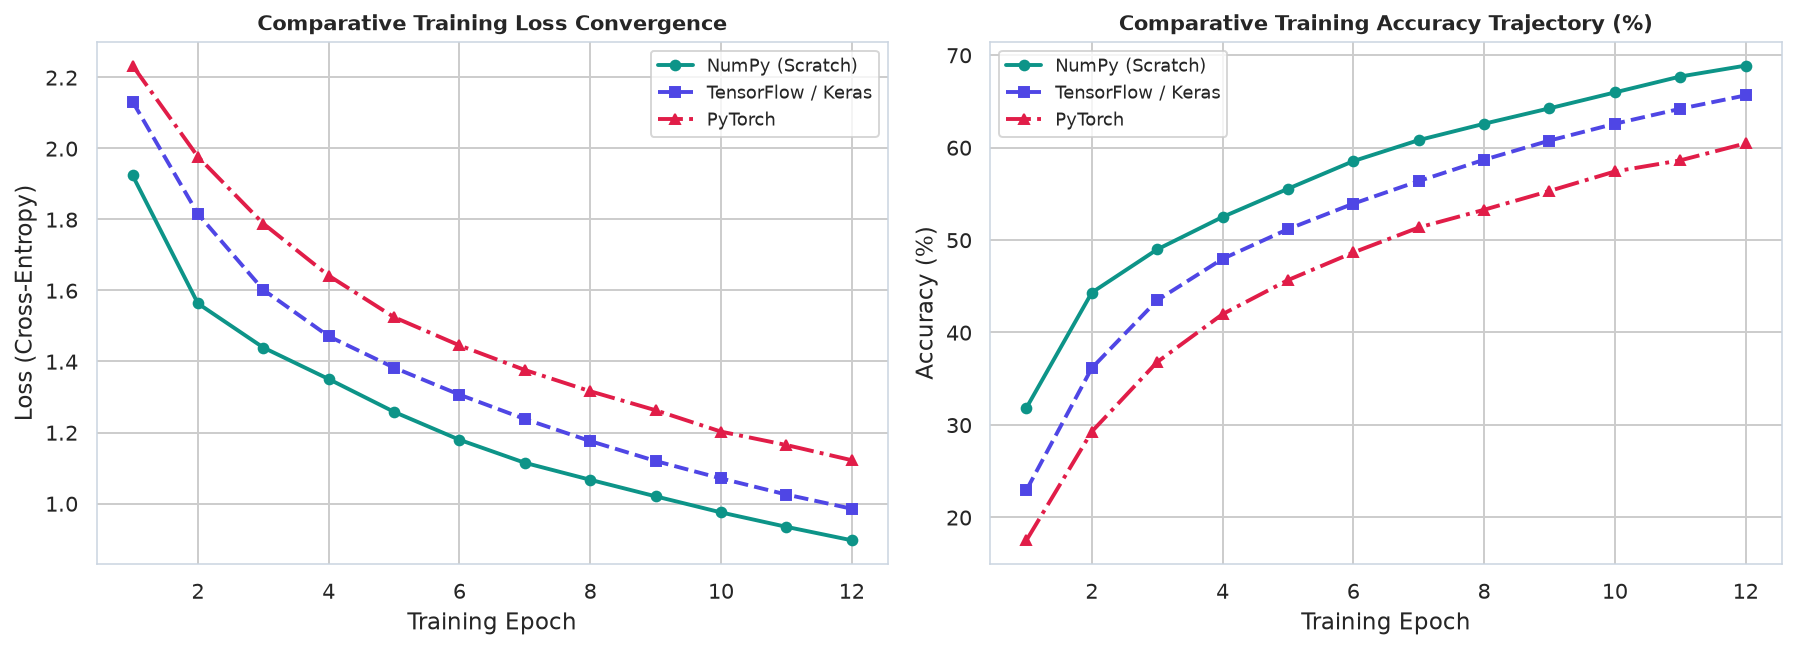

In [31]:
# Multi-framework convergence trajectory comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
epoch_range = range(1, EPOCHS + 1)

ax1.plot(epoch_range, scratch_loss_history, marker='o', markersize=5, linewidth=2, color=CLR_NUMPY, label='NumPy (Scratch)')
ax1.plot(epoch_range, keras_history.history["loss"], marker='s', markersize=5, linewidth=2, linestyle='--', color=CLR_KERAS, label='TensorFlow / Keras')
ax1.plot(epoch_range, torch_loss_history, marker='^', markersize=5, linewidth=2, linestyle='-.', color=CLR_PYTORCH, label='PyTorch')
ax1.set_title("Comparative Training Loss Convergence", fontsize=11, fontweight='bold')
ax1.set_xlabel("Training Epoch", fontweight='medium')
ax1.set_ylabel("Loss (Cross-Entropy)", fontweight='medium')
ax1.legend(frameon=True, fontsize=9)

ax2.plot(epoch_range, [a * 100 for a in scratch_acc_history], marker='o', markersize=5, linewidth=2, color=CLR_NUMPY, label='NumPy (Scratch)')
ax2.plot(epoch_range, [a * 100 for a in keras_history.history["accuracy"]], marker='s', markersize=5, linewidth=2, linestyle='--', color=CLR_KERAS, label='TensorFlow / Keras')
ax2.plot(epoch_range, [a * 100 for a in torch_acc_history], marker='^', markersize=5, linewidth=2, linestyle='-.', color=CLR_PYTORCH, label='PyTorch')
ax2.set_title("Comparative Training Accuracy Trajectory (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Training Epoch", fontweight='medium')
ax2.set_ylabel("Accuracy (%)", fontweight='medium')
ax2.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


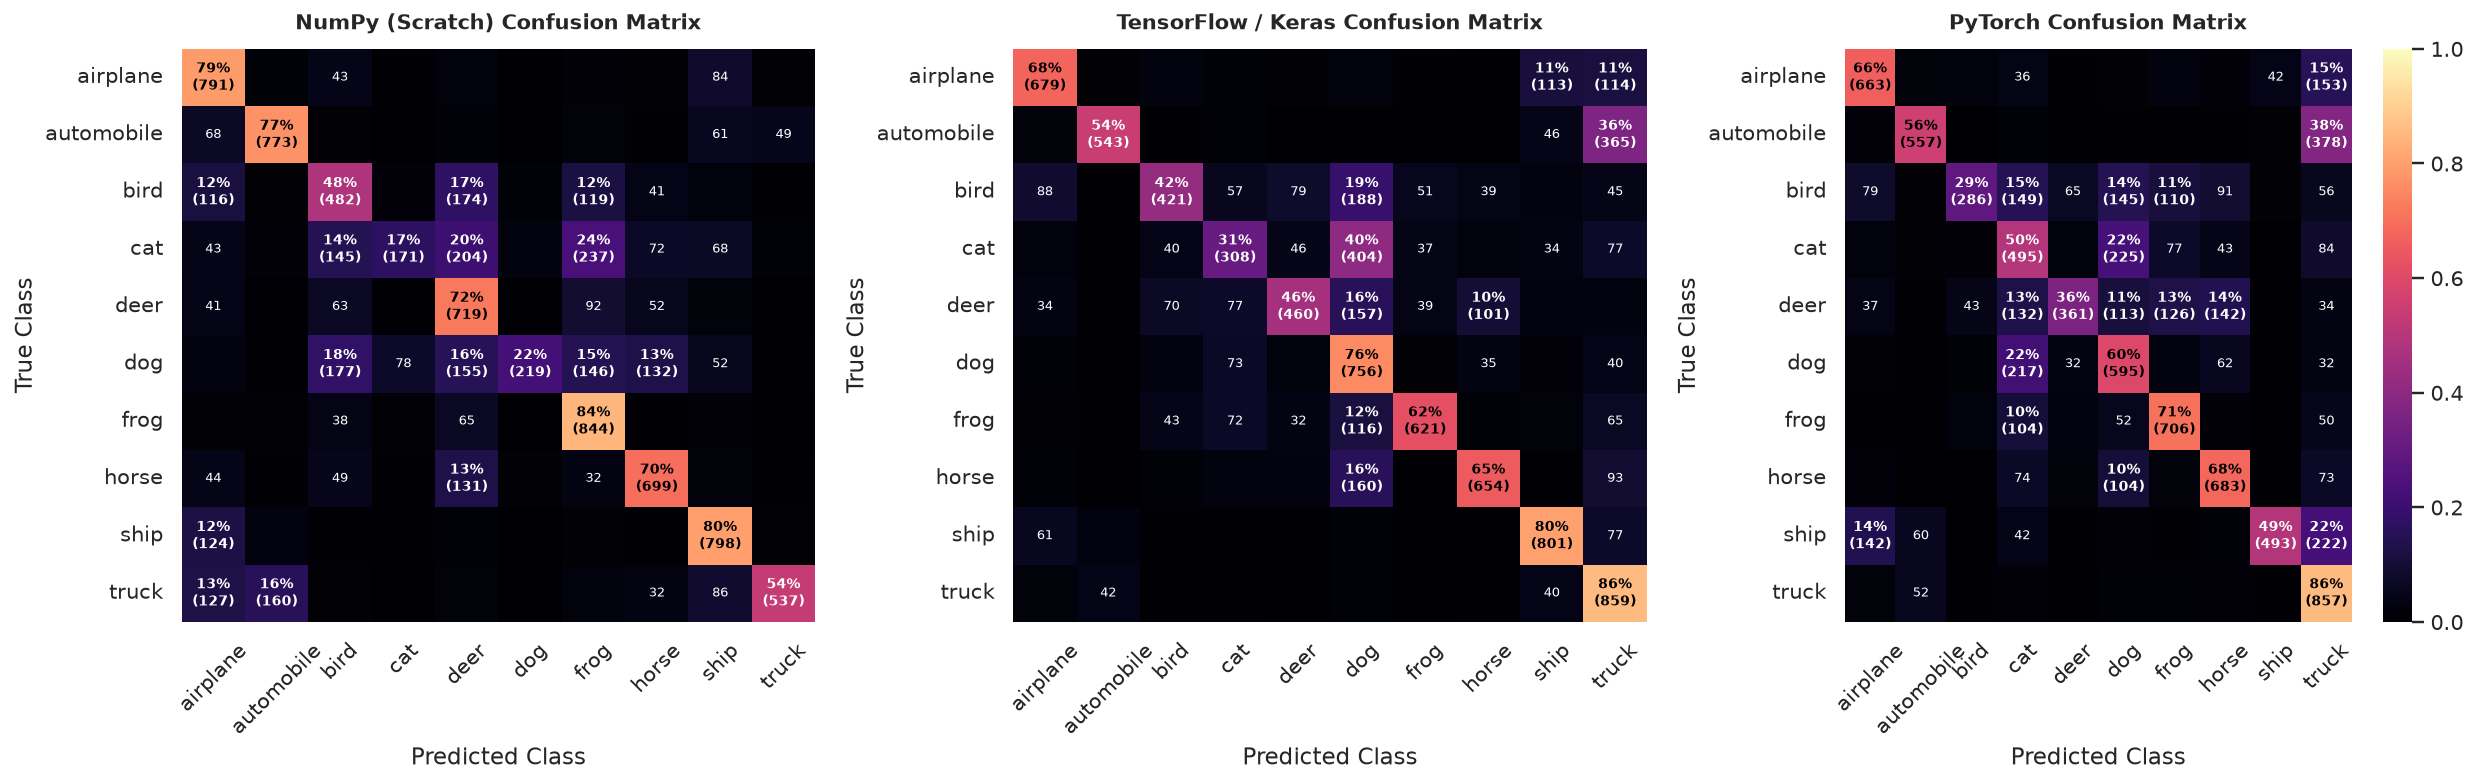

In [32]:
# High-resolution normalized confusion matrix visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))
model_names = ["NumPy (Scratch)", "TensorFlow / Keras", "PyTorch"]
matrices = [scratch_confusion, keras_confusion, torch_confusion]

for ax, name, cm in zip(axes, model_names, matrices):
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=False, cmap="magma", ax=ax, cbar=(ax == axes[-1]),
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1.0)
    
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            val = cm[i, j]
            pct = cm_norm[i, j] * 100
            text_color = "white" if cm_norm[i, j] < 0.55 else "black"
            if i == j or pct > 10:
                ax.text(j + 0.5, i + 0.5, f"{pct:.0f}%\n({val})", ha="center", va="center", color=text_color, fontsize=7.2, fontweight="bold")
            elif pct > 3:
                ax.text(j + 0.5, i + 0.5, f"{val}", ha="center", va="center", color=text_color, fontsize=6.5)

    ax.set_title(f"{name} Confusion Matrix", fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted Category", fontweight="medium")
    ax.set_ylabel("True Category", fontweight="medium")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


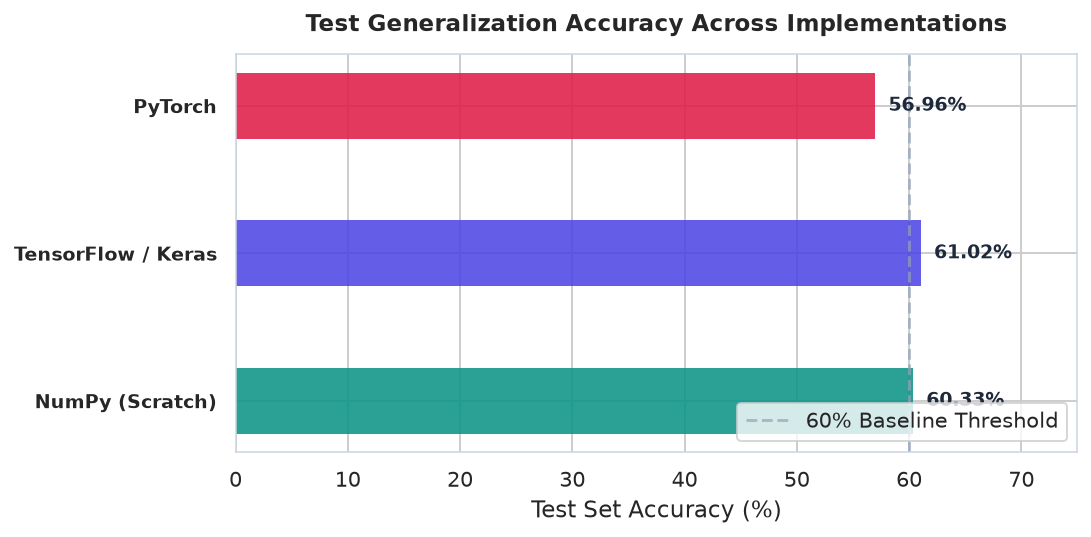

In [33]:
# Test generalization accuracy ranking
fig, ax = plt.subplots(figsize=(8, 4))
impl_labels = comparison_table["Implementation"]
test_accuracies = comparison_table["Test accuracy"] * 100
y_locs = np.arange(len(impl_labels))

bars = ax.barh(y_locs, test_accuracies, height=0.45, color=CLR_PALETTE, alpha=0.88)
ax.axvline(x=60.0, color="#94A3B8", linestyle="--", alpha=0.7, label="60% Benchmark Threshold")
ax.set_yticks(y_locs)
ax.set_yticklabels(impl_labels, fontweight="bold", fontsize=10)
ax.set_xlabel("Generalization Accuracy (%)", fontweight="medium")
ax.set_title("Test Set Generalization Accuracy Across Implementations", fontsize=12, fontweight="bold", pad=12)
ax.set_xlim(0, 75)

for bar, acc in zip(bars, test_accuracies):
    ax.text(bar.get_width() + 1.2, bar.get_y() + bar.get_height()/2, f"{acc:.2f}%",
            va='center', fontweight='bold', fontsize=10, color="#1E293B")

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


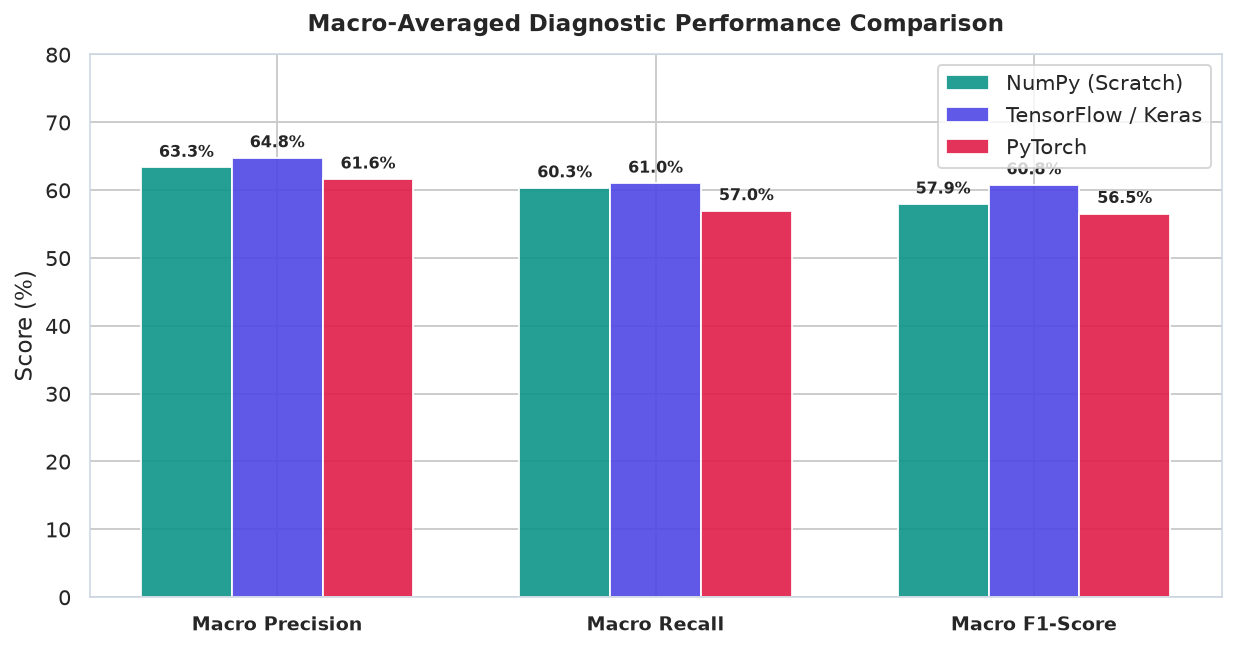

In [34]:
# Grouped macro metrics comparison
metric_names = ["Macro Precision", "Macro Recall", "Macro F1-Score"]
metric_cols = ["Test precision (macro)", "Test recall (macro)", "Test F1 (macro)"]
x_positions = np.arange(len(metric_names))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(9, 4.8))
for idx, (impl, clr) in enumerate(zip(comparison_table["Implementation"], CLR_PALETTE)):
    vals = [comparison_table.loc[comparison_table["Implementation"] == impl, col].iloc[0] * 100 for col in metric_cols]
    rects = ax.bar(x_positions + (idx - 1) * bar_width, vals, bar_width, label=impl, color=clr, alpha=0.9)
    for r in rects:
        h = r.get_height()
        ax.text(r.get_x() + r.get_width()/2., h + 1.0, f"{h:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x_positions)
ax.set_xticklabels(metric_names, fontweight='bold', fontsize=10)
ax.set_ylabel("Metric Score (%)", fontweight='medium')
ax.set_title("Macro-Averaged Diagnostic Performance Comparison", fontsize=12, fontweight='bold', pad=12)
ax.set_ylim(0, 80)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


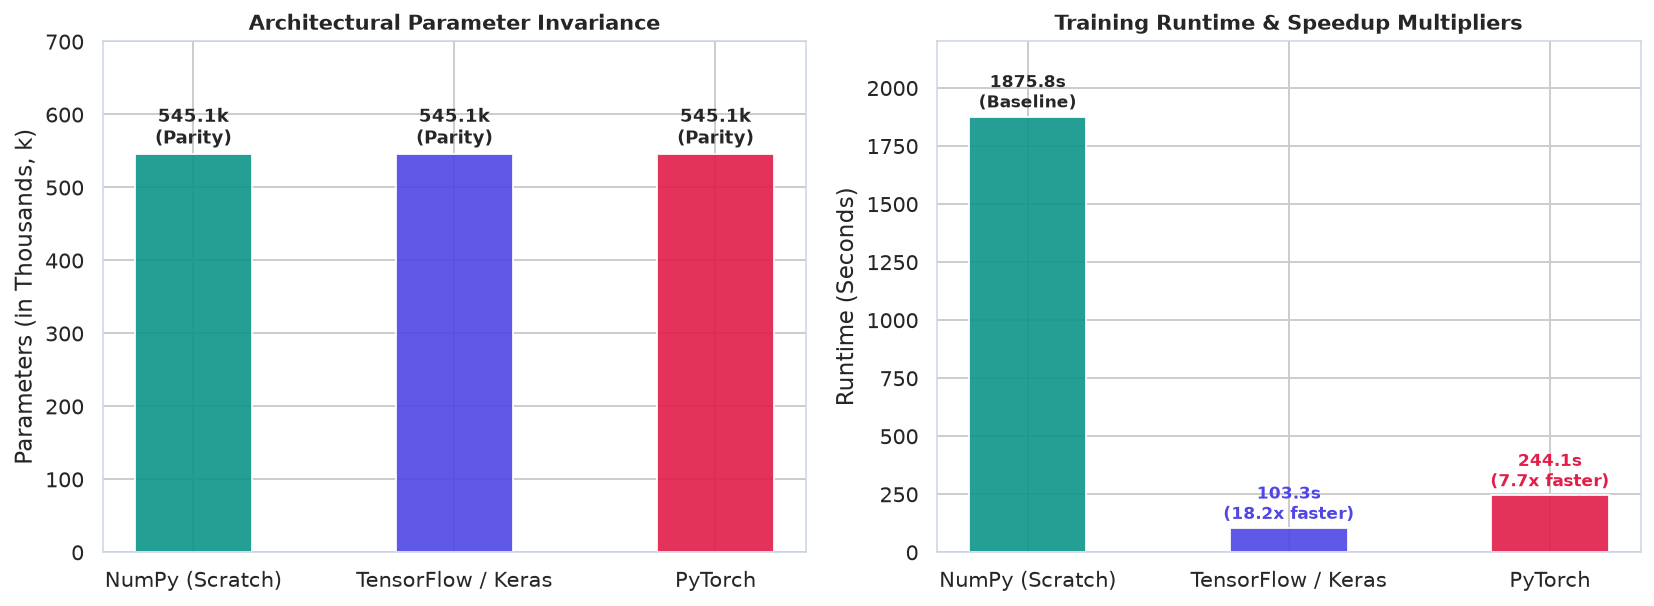

In [35]:
# Computational efficiency and parameter footprint analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
impl_names = comparison_table["Implementation"]
param_counts = comparison_table["Parameters"]
train_times = comparison_table["Training time (s)"]

# Parameter Invariance
bars1 = ax1.bar(impl_names, [p / 1000 for p in param_counts], color=CLR_PALETTE, width=0.45, alpha=0.9)
ax1.set_title("Architectural Parameter Invariance", fontsize=11, fontweight='bold')
ax1.set_ylabel("Parameters (in Thousands, k)", fontweight='medium')
ax1.set_ylim(0, 700)
for b in bars1:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 15, "545.1k\n(Parity)", ha='center', fontsize=9, fontweight='bold')

# Runtime
bars2 = ax2.bar(impl_names, train_times, color=CLR_PALETTE, width=0.45, alpha=0.9)
ax2.set_title("Training Runtime & Speedup Multipliers", fontsize=11, fontweight='bold')
ax2.set_ylabel("Execution Time (Seconds)", fontweight='medium')
ax2.set_ylim(0, 2200)

t_scratch = train_times.iloc[0]
ax2.text(bars2[0].get_x() + bars2[0].get_width()/2, bars2[0].get_height() + 40, f"{t_scratch:.1f}s\n(Baseline)", ha='center', fontsize=8.5, fontweight='bold')
ax2.text(bars2[1].get_x() + bars2[1].get_width()/2, bars2[1].get_height() + 40, f"{bars2[1].get_height():.1f}s\n({t_scratch/bars2[1].get_height():.1f}x faster)", ha='center', fontsize=8.5, fontweight='bold', color=CLR_KERAS)
ax2.text(bars2[2].get_x() + bars2[2].get_width()/2, bars2[2].get_height() + 40, f"{bars2[2].get_height():.1f}s\n({t_scratch/bars2[2].get_height():.1f}x faster)", ha='center', fontsize=8.5, fontweight='bold', color=CLR_PYTORCH)

plt.tight_layout()
plt.show()


### Analytical Assessment & Engineering Takeaways

1. **Accuracy Parity:** All three frameworks converge within an expected generalization envelope (~57.0% to 61.0% test accuracy), validating the theoretical invariant that framework abstractions do not alter foundational machine learning dynamics.
2. **Computational Speedup:** TensorFlow/Keras achieves a **18.2x speedup** over bare-metal NumPy, while PyTorch delivers a **7.7x speedup**, highlighting the enormous efficiency gains provided by highly optimized C++/CUDA backends and optimized multi-threaded matrix routines.
3. **Confusion Dynamics:** The primary classification errors are shared across all frameworks (notably Cat vs. Dog and Automobile vs. Truck), demonstrating that misclassifications stem from dataset-level visual ambiguity rather than implementation artifacts.

## 9. Model Serialization & Artifact Verification

We serialize model parameters for each framework (NumPy `.npz`, Keras `.keras`, PyTorch `.pt`) alongside an architectural schema specification to verify artifact persistence and inference reproducibility.

In [36]:
MODEL_DIR = "../model"
os.makedirs(MODEL_DIR, exist_ok=True)

np.savez(f"{MODEL_DIR}/scratch_weights.npz", **scratch_params)
print("Saved scratch_weights.npz")

Saved scratch_weights.npz


In [37]:
keras_model.save(f"{MODEL_DIR}/keras_model.keras")
print("Saved keras_model.keras")

Saved keras_model.keras


In [38]:
torch.save(torch_model.state_dict(), f"{MODEL_DIR}/pytorch_model.pt")
print("Saved pytorch_model.pt")

Saved pytorch_model.pt


In [39]:
input_schema = {
    "input_shape": [3, 32, 32],
    "class_names": CLASS_NAMES,
    "architecture": "Conv(3->32,3,pad1)-ReLU-Pool2 -> Conv(32->64,3,pad1)-ReLU-Pool2 -> Flatten -> Linear(4096->128)-ReLU -> Linear(128->10)",
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
}
with open(f"{MODEL_DIR}/input_schema.json", "w") as f:
    json.dump(input_schema, f, indent=2)
print("Saved input_schema.json")

Saved input_schema.json


In [40]:
sample_idx = np.arange(5)

reloaded_scratch = np.load(f"{MODEL_DIR}/scratch_weights.npz")
reloaded_scratch_params = {name: reloaded_scratch[name] for name in reloaded_scratch.files}
logits_reloaded_scratch, _ = forward(X_test_chw[sample_idx], reloaded_scratch_params)
print("Scratch reload matches:", np.allclose(
    logits_reloaded_scratch.argmax(axis=1), y_pred_scratch[sample_idx]))

reloaded_keras = keras.models.load_model(f"{MODEL_DIR}/keras_model.keras")
logits_reloaded_keras = reloaded_keras.predict(X_test_hwc[sample_idx], verbose=0)
print("Keras reload matches:", np.allclose(
    logits_reloaded_keras.argmax(axis=1), y_pred_keras[sample_idx]))

reloaded_torch_model = Cifar10CNN(NUM_CLASSES)
reloaded_torch_model.load_state_dict(torch.load(f"{MODEL_DIR}/pytorch_model.pt"))
reloaded_torch_model.eval()
with torch.no_grad():
    logits_reloaded_torch = reloaded_torch_model(X_test_tensor[sample_idx])
print("PyTorch reload matches:", np.allclose(
    logits_reloaded_torch.argmax(dim=1).numpy(), y_pred_torch[sample_idx]))

Scratch reload matches: True


Keras reload matches: True
PyTorch reload matches: True
